<a href="https://colab.research.google.com/github/alirezaataei1375-eng/Convergence-rate-QLLG-Bear-2/blob/main/Convergence_rate_QLLG%2C_Bear_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

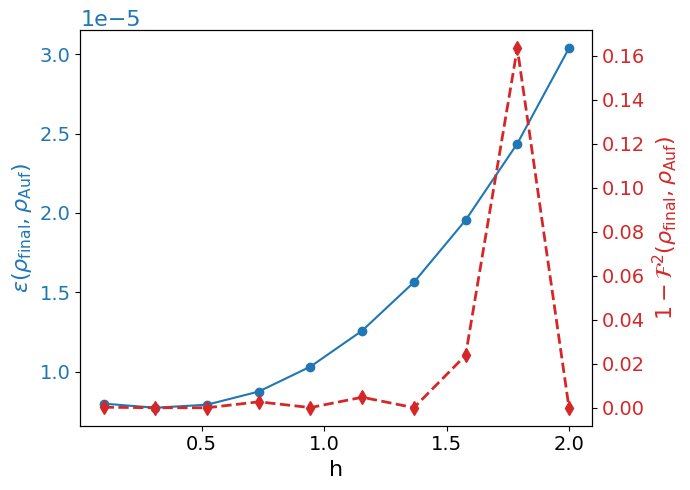

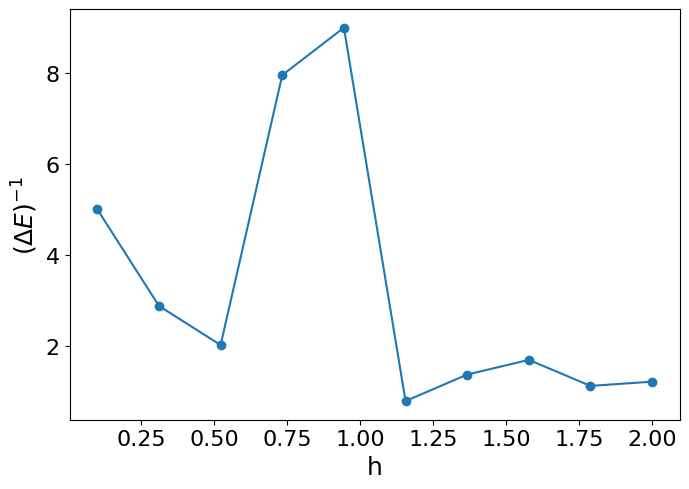

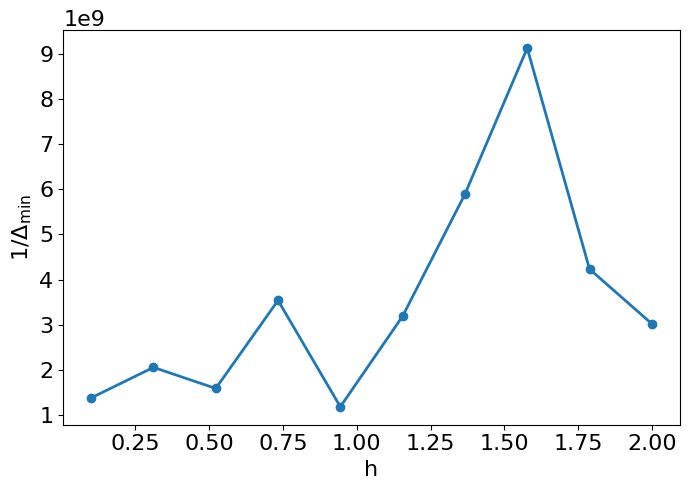

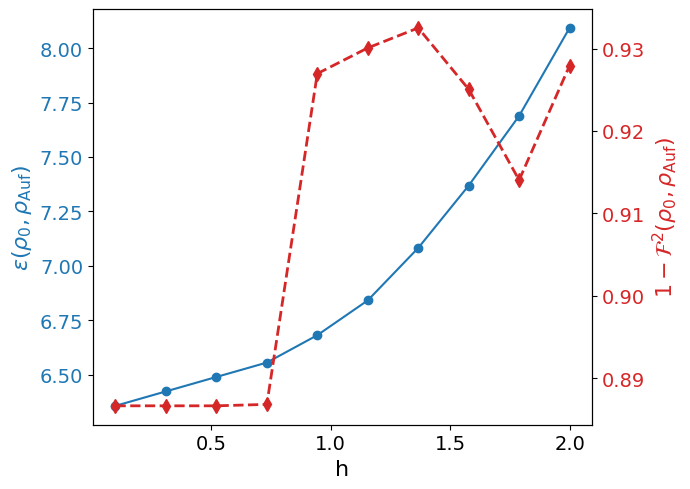

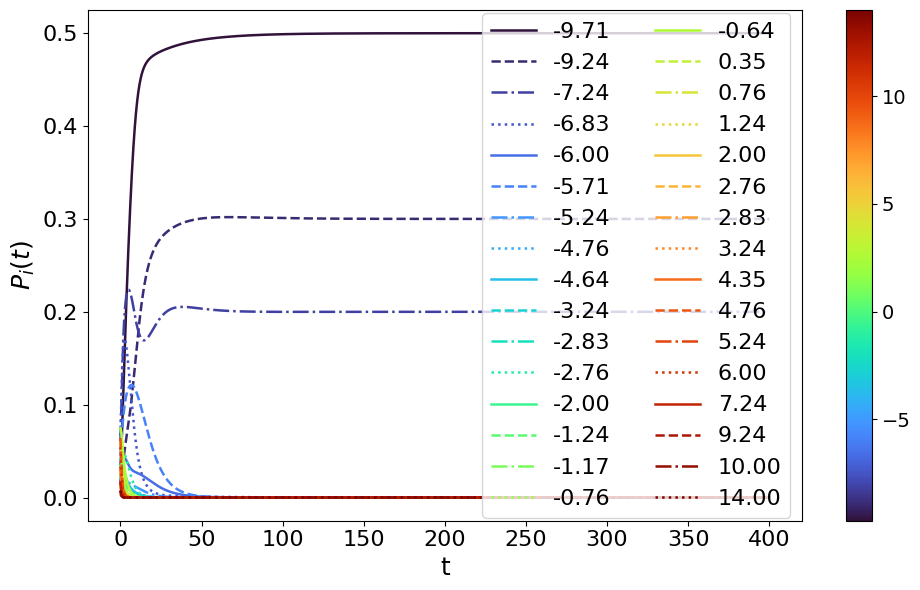

'\n# ==================================================\n# SEPARATE POPULATION DYNAMICS FOR h = 1\n# ==================================================\n\nh_pop = 1.0\n\nBx, By, Bz = h_pop * np.array([1.0, 0.0, 0.0])\n\nH_pop = heisenberg_chain_fast(\n    J, N, ops,\n    Bx=Bx,\n    By=By,\n    Bz=Bz\n)\n\n# Energy spectrum\nE_pop, V_pop = np.linalg.eigh(H_pop)\nVdag_pop = V_pop.conj().T\n\n# QLLG dynamics only for h = 1\nrho_list_pop, times_pop = propagate_kappa_fast(\n    rho0,\n    H_pop,\n    hbar,\n    kappa,\n    nmax,\n    t_final,\n    dt\n)\n\n# Population in each energy eigenstate:\n#\n# p_i(t) = <E_i|rho(t)|E_i>\n#\npopulation_h1 = np.array([\n    np.real(np.diag(Vdag_pop @ rho @ V_pop))\n    for rho in rho_list_pop\n])\n\n# Remove tiny numerical negative values\npopulation_h1 = np.maximum(population_h1, 0.0)\n\n# Normalize each time slice\npopulation_h1 /= (\n    np.sum(population_h1, axis=1, keepdims=True) + 1e-14\n)\n\n\n\n\n# =============================================

In [ ]:
import numpy as np
from numpy import kron
from numpy.linalg import norm
import matplotlib.pyplot as plt
from scipy.stats import unitary_group
from scipy.linalg import sqrtm
from numpy.linalg import svd
# ==================================================
# Pauli matrices
# ==================================================
sx = np.array([[0,1],[1,0]],dtype=complex)
sy = np.array([[0,-1j],[1j,0]],dtype=complex)
sz = np.array([[1,0],[0,-1]],dtype=complex)
I2 = np.eye(2,dtype=complex)

def comm(A,B):
    return A @ B - B @ A

# ==================================================
# Precompute operators
# ==================================================
def op_n(A, n, N):
    res = 1
    for i in range(N):
        res = kron(res, A if i==n else I2)
    return res

def precompute_ops(N):
    ops = {}
    for i in range(N):
        ops[('x', i)] = op_n(sx, i, N)
        ops[('y', i)] = op_n(sy, i, N)
        ops[('z', i)] = op_n(sz, i, N)
    return ops


def trace_norm(A):
    return np.sum(svd(A, compute_uv=False))

# ==================================================
# Commutator norm
# ==================================================
def commutator_norm_sq(rho, H):
    C = comm(rho, H)
    return np.real(np.trace(C.conj().T @ C))

# ==================================================
# Hamiltonian
# ==================================================
def heisenberg_chain_fast(J, N, ops, Bx=0.0, By=0.0, Bz=0.0, periodic=False):
    dim = 2**N
    H = np.zeros((dim,dim),dtype=complex)

    for i in range(N-1):
        H += J * (ops[('x',i)] @ ops[('x',i+1)] +
                  ops[('y',i)] @ ops[('y',i+1)] +
                  ops[('z',i)] @ ops[('z',i+1)])

    if periodic:
        H += J * (ops[('x',N-1)] @ ops[('x',0)] +
                  ops[('y',N-1)] @ ops[('y',0)] +
                  ops[('z',N-1)] @ ops[('z',0)])

    for i in range(N):
        H += Bx * ops[('x',i)]
        H += By * ops[('y',i)]
        H += Bz * ops[('z',i)]

    return H

# ==================================================
# Mixed state
# ==================================================
def mixed_initial_state(psi_list, weights=None):
    if weights is None:
        weights = np.ones(len(psi_list))/len(psi_list)
    rho = 0
    for w, psi in zip(weights, psi_list):
        rho += w * np.outer(psi, psi.conj())
    return rho

# ==================================================
# Polynomial utilities
# ==================================================
def poly_add(p,q):
    n=max(len(p),len(q))
    out=[np.zeros_like(p[0]) for _ in range(n)]
    for i in range(len(p)): out[i]+=p[i]
    for i in range(len(q)): out[i]+=q[i]
    return out

def poly_comm(p,q):
    deg=len(p)+len(q)-2
    out=[np.zeros_like(p[0]) for _ in range(deg+1)]
    for i,A in enumerate(p):
        for j,B in enumerate(q):
            out[i+j]+=comm(A,B)
    return out

def poly_derivative(p):
    out=[]
    for m in range(1,len(p)):
        out.append(m*p[m])
    return out if out else [np.zeros_like(p[0])]

def poly_integrate(p):
    out=[np.zeros_like(p[0])]
    for m,A in enumerate(p):
        out.append(A/(m+1))
    return out

def poly_eval(p,t):
    out=np.zeros_like(p[0])
    for m,A in enumerate(p):
        out+=A*(t**m)
    return out

# ==================================================
# κ-series
# ==================================================
def rho_kappa_series(dt,hbar,kappa,rho0,H,nmax):
    d = H.shape[0]
    tau = 1.0
    rho_polys = [[rho0.copy()]]

    for j in range(nmax):
        integrand = [np.zeros((d,d),dtype=complex)]
        for k in range(j+1):
            rho_k_poly = rho_polys[k]
            rho_jk_poly = rho_polys[j-k]

            dot_rho_jk = [A/dt for A in poly_derivative(rho_jk_poly)]
            comm_H = [1j/hbar*comm(A,H) for A in rho_jk_poly]

            total = poly_add(dot_rho_jk, comm_H)
            integrand = poly_add(integrand, poly_comm(rho_k_poly, total))

        rho_next = [1j*dt*A for A in poly_integrate(integrand)]
        rho_polys.append(rho_next)

    return sum(kappa**j * poly_eval(rho_polys[j], tau) for j in range(nmax+1))

# ==================================================
# propagation
# ==================================================
def propagate_kappa_fast(rho0,H,hbar,kappa,nmax,t_final,dt):
    times = np.arange(0,t_final+dt,dt)
    rho_list = [rho0.copy()]

    for _ in times[1:]:
        rho_next = rho_kappa_series(dt,hbar,kappa,rho_list[-1],H,nmax)
        rho_list.append(rho_next)

    return np.array(rho_list), times

# ==================================================
# Fidelity
# ==================================================
def fidelity(rho, sigma):
    sqrt_rho = sqrtm(rho)
    inner = sqrt_rho @ sigma @ sqrt_rho
    return np.real(np.trace(sqrtm(inner)))**2

# ==================================================
# PARAMETERS
# ==================================================
N = 5
J = 1.0
hbar = 1.0
kappa = 0.2
nmax = 4
t_final = 400
dt = 0.05

#Try dt=0.01, 0.001 and t_final = 200, 400, 600
#weights = [0.04, 0.12, 0.20, 0.28, 0.36]
weights = [0.5,0.3,0.2]
ops = precompute_ops(N)

dim = 2**N
U = unitary_group.rvs(dim, random_state=42)
psi_list = [U[:,i] for i in range(len(weights))]

rho0 = mixed_initial_state(psi_list, weights)

h_values = np.linspace(0.1, 2.0, 10)


# ==================================================
# storage
# ==================================================
gap_inverse_min = []
energy_errors = []
comm_strength = []
conv_rates = []
fidelity_errors = []
trace_errors = []
coherence_times = []
energy_errors_init = []
fidelity_errors_init = []
trace_errors_init = []
population_data = []
energy_data = []
effective_gap_inverse = []
# ==================================================
# MAIN LOOP
# ==================================================
for h in h_values:

    Bx, By, Bz = h * np.array([1.0,0.0,0.0])
    H = heisenberg_chain_fast(J, N, ops, Bx=Bx, By=By, Bz=Bz)

    C0 = commutator_norm_sq(rho0, H)
    comm_strength.append(C0)

    # spectrum
    E_vals, V = np.linalg.eigh(H)
    Vdag = V.conj().T


    # dynamics FIRST (FIXED ORDER)
    rho_list, times = propagate_kappa_fast(rho0,H,hbar,kappa,nmax,t_final,dt)
    # populations in energy basis
    populations_t = []

    for rho in rho_list:
        rho_E = Vdag @ rho @ V
        pops = np.real(np.diag(rho_E))
        populations_t.append(pops)

    populations_t = np.array(populations_t)
    # store population dynamics for h = 1
    if np.isclose(h, 2.0, atol=1e-8):

        order = np.argsort(E_vals)

        times_h1 = times.copy()
        pops_h1 = populations_t[:, order]
        energies_h1 = E_vals[order]
    rho_init = rho_list[0]
    energy_init = np.real(np.trace(rho_init @ H))
    rho_final = rho_list[-1]

    # ==================================================
    # coherence-weighted convergence time
    # ==================================================

    rho_E = Vdag @ rho_final @ V

    threshold = 1e-6
    target = 1e-7   # because ln(|rho_ij|)+7 was your proposal

    timescales = []

    for i in range(len(E_vals)):
        for j in range(len(E_vals)):

            if i == j:
                continue

            rij = abs(rho_E[i,j])

            if rij > threshold:

                gap = abs(E_vals[i] - E_vals[j])

                if gap > 1e-12:

                    tij = (np.log(rij) + 7.0)/gap

                    timescales.append(tij)

    if len(timescales) > 0:
        coherence_times.append(np.max(timescales))
    else:
        coherence_times.append(0.0)






    # ==================================================
    # spectral projection (NOW SAFE)
    # ==================================================
    overlaps = np.real(np.diag(Vdag @ rho_final @ V))
    overlaps = np.maximum(overlaps, 0)
    overlaps /= overlaps.sum()
    gmin = np.inf

    for i in range(len(E_vals)):
        for j in range(i+1, len(E_vals)):

            dp = abs(overlaps[i] - overlaps[j])
            dE = abs(E_vals[i] - E_vals[j])

            g = dp * dE

            if g > 1e-10:
               gmin = min(gmin, g)

    effective_gap_inverse.append(1/gmin)
    population_data.append(overlaps.copy())
    energy_data.append(E_vals.copy())
    eps = 1e-6
    k = np.sum(overlaps > eps)
    k = np.clip(k, 0, len(E_vals)-2)

    gap_k = E_vals[k+1] - E_vals[k]
    gap_inverse_min.append(1.0/(np.abs(gap_k)+1e-12))






    # ==================================================
    # convergence rate
    # ==================================================
    energy_list = np.array([np.real(np.trace(rho @ H)) for rho in rho_list])
    E_inf = energy_list[-1]
    E_err = np.abs(energy_list - E_inf) + 1e-12

    cut = max(5, len(times)//5)
    gamma = -np.polyfit(times[:cut], np.log(E_err[:cut]), 1)[0]
    conv_rates.append(gamma)

    # energy error
    spectral_energy = np.sum(overlaps * E_vals)
    energy_errors.append(abs(np.real(np.trace(rho_final @ H)) - spectral_energy))


    # ==================================================
    # ordered energy-biased diagonal state
    # ==================================================

    overlaps = np.real(np.diag(Vdag @ rho_final @ V))
    overlaps = np.maximum(overlaps, 0)
    overlaps = overlaps / (np.sum(overlaps) + 1e-12)

    # enforce energy ordering (low energy = index 0)
    order = np.argsort(E_vals)
    E_sorted = E_vals[order]
    p_sorted = overlaps[order]

    # enforce monotone decreasing weights
    w_sorted = np.maximum.accumulate(p_sorted[::-1])[::-1]

    # renormalize
    w_sorted = w_sorted / (np.sum(w_sorted) + 1e-12)

    rho_diag = V[:, order] @ np.diag(w_sorted) @ V[:, order].conj().T

    #rho_diag = V @ np.diag(overlaps) @ Vdag
    trace_errors_init.append(trace_norm(rho_init - rho_diag))
    fidelity_errors_init.append(1 - fidelity(rho_init, rho_diag))
    trace_errors.append(trace_norm(rho_final - rho_diag))
    fidelity_errors.append(1 - fidelity(rho_final, rho_diag))
    energy_errors_init.append(
    abs(np.real(np.trace(rho_init @ H)) - np.sum(overlaps * E_vals))
)
# ==================================================
# PLOT 1
# ==================================================
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(h_values, energy_errors, "o-", color="tab:blue")
ax1.set_xlabel("h", fontsize=16)
ax1.set_ylabel(
    r"$\varepsilon(\rho_{\mathrm{final}},\rho_{\mathrm{Auf}})$",
    color="tab:blue",
    fontsize=16
)
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.yaxis.get_offset_text().set_fontsize(16)
#ax1.yaxis.get_offset_text().set_fontweight('bold')

ax2 = ax1.twinx()

ax2.plot(
    h_values,
    fidelity_errors,
    "d--",
    color="tab:red",
    linewidth=2,
    markersize=7,
    label=r"$1-\mathcal{F}^2(\rho_{\mathrm{final}},\rho_{\mathrm{Auf}})$"
)

ax2.set_ylabel(
    r"$1-\mathcal{F}^2(\rho_{\mathrm{final}},\rho_{\mathrm{Auf}})$",
    color="tab:red",
    fontsize=16
)

ax2.tick_params(
    axis='y',
    labelcolor="tab:red"
)

ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

# ==================================================
# PLOT 2
# ==================================================
plt.figure(figsize=(7,5))
plt.plot(h_values, gap_inverse_min, "o-")
plt.xlabel("h", fontsize=18)
plt.ylabel(r"$(\Delta E)^{-1}$", fontsize=18)
# Tick label size (VERY IMPORTANT)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.title("Boundary spectral gap at k")
plt.tight_layout()
plt.show()



plt.figure(figsize=(7,5))

plt.plot(
    h_values,
    effective_gap_inverse,
    "o-",
    linewidth=2
)

plt.xlabel("h", fontsize=16)
plt.ylabel(
    r"$1/\Delta_{\mathrm{min}}$",
    fontsize=16
)

ax = plt.gca()
ax.yaxis.get_offset_text().set_fontsize(16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

# ==================================================
# PLOT 3
# ==================================================

fig, ax1 = plt.subplots(figsize=(7,5))

ax1.plot(h_values, energy_errors_init, "o-", color="tab:blue")
ax1.set_xlabel("h", fontsize=16)
ax1.set_ylabel(r"$\varepsilon(\rho_0,\rho_{\mathrm{Auf}})$", color="tab:blue", fontsize=16)
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()

ax2.plot(
    h_values,
    fidelity_errors_init,
    "d--",
    color="tab:red",
    linewidth=2,
    markersize=7
)

ax2.set_ylabel(r"$1-\mathcal{F}^2(\rho_0,\rho_{\mathrm{Auf}})$", color="tab:red", fontsize=16)
ax2.tick_params(axis='y', labelcolor="tab:red")

ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='both', labelsize=14)

#plt.title("Initial state errors vs h")
plt.tight_layout()
plt.show()



# ==================================================
# PLOT 4 : Energy populations vs time for h = 2
# ==================================================

if pops_h1 is not None:

    plt.figure(figsize=(10, 6))

    cmap = plt.cm.turbo
    linestyles = ['-', '--', '-.', ':']

    nlevels = len(energies_h1)

    for n in range(nlevels):

        plt.plot(
        times_h1,
        pops_h1[:, n],
        color=cmap(n/(nlevels-1)),
        linestyle=linestyles[n % len(linestyles)],
        linewidth=1.8,
        label=f"{energies_h1[n]:.2f}"
    )


    plt.xlabel("t", fontsize=18)
    plt.ylabel(r"$P_i(t)$", fontsize=18)
    #plt.title("Energy-level populations for $h=1$", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    sm = plt.cm.ScalarMappable(
        cmap=cmap,
        norm=plt.Normalize(
            vmin=np.min(energies_h1),
            vmax=np.max(energies_h1)
        )
    )

    ax = plt.gca()
    cbar = plt.colorbar(sm, ax=ax)
    #cbar.set_label("Energy eigenvalue", fontsize=16)
    cbar.ax.tick_params(labelsize=14)
    plt.tight_layout()
    plt.legend(
    fontsize=16,
    ncol=2,
    loc="center right",
    frameon=True
)


    plt.show()


